# Этап 3: Моделирование
## Предсказание выживаемости на Титанике

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

## 1. Подготовка

In [28]:
# Загружаем обработанные данные
train = pd.read_csv('../data/train_processed.csv')
test = pd.read_csv('../data/test_processed.csv')

print(f"Обучающая выборка: {train.shape}")
print(f"Тестовая выборка: {test.shape}")
print(f"\nКолонки в train:\n{train.columns.tolist()}")

Обучающая выборка: (891, 43)
Тестовая выборка: (418, 42)

Колонки в train:
['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'FamilySize', 'IsAlone', 'FarePerPerson', 'Embarked_Q', 'Embarked_S', 'Title_Col', 'Title_Countess', 'Title_Don', 'Title_Dr', 'Title_Jonkheer', 'Title_Lady', 'Title_Major', 'Title_Master', 'Title_Miss', 'Title_Mlle', 'Title_Mme', 'Title_Mr', 'Title_Mrs', 'Title_Ms', 'Title_Rev', 'Title_Sir', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_U', 'AgeGroup_Child', 'AgeGroup_Infant', 'AgeGroup_Senior', 'AgeGroup_Teen', 'AgeGroup_YoungAdult']


In [29]:
# Целевая переменная
y = train['Survived']

# Признаки (всё, кроме Survived и PassengerId)
X = train.drop(['Survived', 'PassengerId'], axis=1)

# Сохраняем PassengerId для теста
test_ids = test['PassengerId']
X_test = test.drop(['PassengerId'], axis=1)

print(f"Признаки X: {X.shape}")
print(f"Целевая y: {y.shape}")
print(f"Тест X_test: {X_test.shape}")

Признаки X: (891, 41)
Целевая y: (891,)
Тест X_test: (418, 41)


In [30]:
# Находим колонки, которые есть в test, но нет в train (исключая PassengerId)
test_cols = set(X_test.columns)
train_cols = set(X.columns)

extra_in_test = test_cols - train_cols
missing_in_test = train_cols - test_cols

print("Колонки в test, которых нет в train:")
print(extra_in_test)
print(f"\nКолонок в train, которых нет в test: {len(missing_in_test)}")

Колонки в test, которых нет в train:
set()

Колонок в train, которых нет в test: 0


In [31]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Обучающая: {X_train.shape}")
print(f"Валидационная: {X_val.shape}")
print(f"\nРаспределение выживших в train: {y_train.value_counts(normalize=True).values}")
print(f"Распределение выживших в val: {y_val.value_counts(normalize=True).values}")

Обучающая: (712, 41)
Валидационная: (179, 41)

Распределение выживших в train: [0.61657303 0.38342697]
Распределение выживших в val: [0.61452514 0.38547486]


In [32]:
# Выбираем числовые колонки
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print(f"Числовые колонки ({len(numeric_cols)}): {numeric_cols[:10]}...")

# Масштабируем
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val_scaled[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Масштабирование выполнено")

Числовые колонки (10): ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'FamilySize', 'IsAlone', 'FarePerPerson']...
Масштабирование выполнено


## 2. Обучим первую модель (Logistic Regression)

In [33]:
# Создаём и обучаем модель
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Предсказываем
y_pred_lr = lr.predict(X_val_scaled)
y_proba_lr = lr.predict_proba(X_val_scaled)[:, 1]

# Метрики
print("Logistic Regression\n")
print(f"Accuracy: {accuracy_score(y_val, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_lr):.4f}")
print(f"F1-score: {f1_score(y_val, y_pred_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_proba_lr):.4f}")

Logistic Regression

Accuracy: 0.8212
Precision: 0.7937
Recall: 0.7246
F1-score: 0.7576
ROC-AUC: 0.8630


## 3. Обучим вторую модель (Random Forest)

In [34]:
# Создаём и обучаем модель
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train_scaled, y_train)

# Предсказываем
y_pred_rf = rf.predict(X_val_scaled)
y_proba_rf = rf.predict_proba(X_val_scaled)[:, 1]

# Метрики
print("Random Forest\n")
print(f"Accuracy: {accuracy_score(y_val, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_rf):.4f}")
print(f"F1-score: {f1_score(y_val, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_proba_rf):.4f}")

Random Forest

Accuracy: 0.7877
Precision: 0.7385
Recall: 0.6957
F1-score: 0.7164
ROC-AUC: 0.8145


## 4. Сравнение моделей

In [ ]:
# Собираем результаты
results = pd.DataFrame({
    'Модель': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_val, y_pred_lr), accuracy_score(y_val, y_pred_rf)],
    'Precision': [precision_score(y_val, y_pred_lr), precision_score(y_val, y_pred_rf)],
    'Recall': [recall_score(y_val, y_pred_lr), recall_score(y_val, y_pred_rf)],
    'F1-score': [f1_score(y_val, y_pred_lr), f1_score(y_val, y_pred_rf)],
    'ROC-AUC': [roc_auc_score(y_val, y_proba_lr), roc_auc_score(y_val, y_proba_rf)]
})

print("Сравнение моделей\n")
print(results.round(4))

=== Сравнение моделей ===
                Модель  Accuracy  Precision  Recall  F1-score  ROC-AUC
0  Logistic Regression    0.8212     0.7937  0.7246    0.7576   0.8630
1        Random Forest    0.7877     0.7385  0.6957    0.7164   0.8145


## 5. Матрица ошибок (Confusion Matrix)

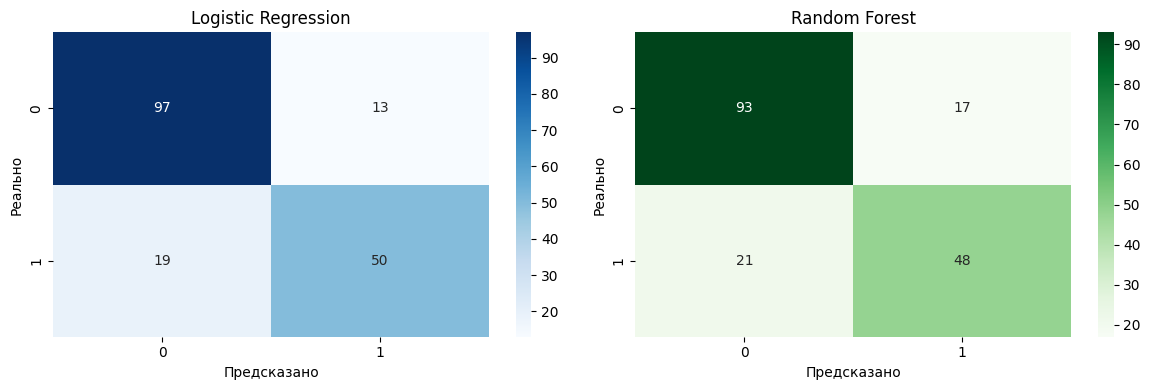

In [36]:
# Для лучшей модели (выбери Random Forest, если он лучше)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Logistic Regression
cm_lr = confusion_matrix(y_val, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Предсказано')
axes[0].set_ylabel('Реально')

# Random Forest
cm_rf = confusion_matrix(y_val, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Предсказано')
axes[1].set_ylabel('Реально')

plt.tight_layout()
plt.show()

## 6. Важность признаков (для Random Forest)

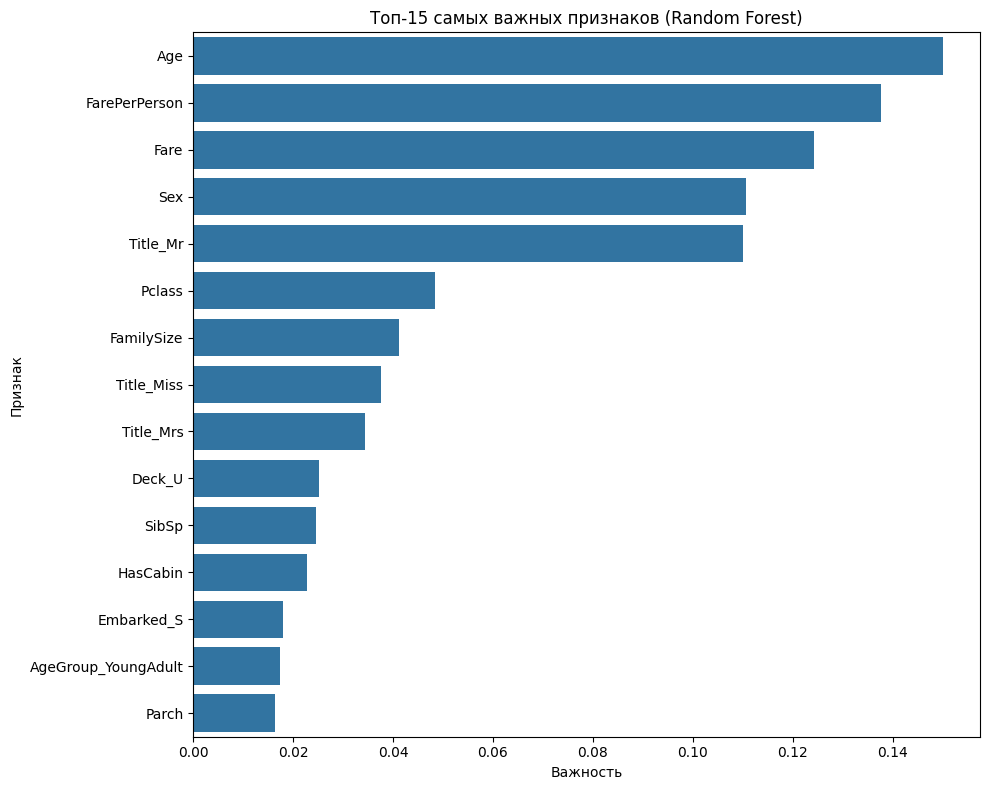

          Признак  Важность
2             Age  0.150007
9   FarePerPerson  0.137594
5            Fare  0.124262
1             Sex  0.110598
23       Title_Mr  0.110066
0          Pclass  0.048342
7      FamilySize  0.041283
20     Title_Miss  0.037616
24      Title_Mrs  0.034389
35         Deck_U  0.025237


In [37]:
# Только для Random Forest
feature_importance = pd.DataFrame({
    'Признак': X.columns,
    'Важность': rf.feature_importances_
}).sort_values('Важность', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Важность', y='Признак', data=feature_importance.head(15))
plt.title('Топ-15 самых важных признаков (Random Forest)')
plt.tight_layout()
plt.show()

print(feature_importance.head(10))

## 7. Предсказание на тестовых данных

In [38]:
# Используем лучшую модель (Random Forest)
final_predictions = rf.predict(X_test_scaled)

# Создаём файл для отправки
submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived': final_predictions
})

submission.to_csv('../data/submission.csv', index=False)
print("✅ Файл предсказаний сохранён: ../data/submission.csv")
print(submission.head(10))

✅ Файл предсказаний сохранён: ../data/submission.csv
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         1
4          896         0
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0


## 8. Выводы

In [39]:
print("ВЫВОДЫ\n")
print(f"\nЛучшая модель: Random Forest")
print(f"Accuracy на валидации: {accuracy_score(y_val, y_pred_rf):.4f}")
print(f"ROC-AUC на валидации: {roc_auc_score(y_val, y_proba_rf):.4f}")
print(f"\nСамые важные признаки:")
for i, row in feature_importance.head(5).iterrows():
    print(f"  {row['Признак']}: {row['Важность']:.4f}")

ВЫВОДЫ


Лучшая модель: Random Forest
Accuracy на валидации: 0.7877
ROC-AUC на валидации: 0.8145

Самые важные признаки:
  Age: 0.1500
  FarePerPerson: 0.1376
  Fare: 0.1243
  Sex: 0.1106
  Title_Mr: 0.1101
